# sox32 enhancer — analysis walkthrough

A step-by-step, reviewable record of the cross-cell-type ChromBPNet analysis of the zebrafish **sox32** (SOX17 analog) enhancer reporter construct.

**Question.** In a reporter assay this enhancer is ON in DE and OFF in PGT, with reported binding by **EOMES, T (TBXT), FOXH1**. Does our 22-cell-type ChromBPNet ensemble reproduce (a) the accessibility readout and (b) the TF binding?

**How to read this notebook.** It is a **viewer**: it loads precomputed outputs (`outputs/*.npz`, `*.csv`) and displays figures (`figures/*.png`). **No heavy compute runs here** — predictions/contributions/sweeps are produced by the numbered scripts on SLURM (`run_all.sh`). Each section explains *what was done*, *how*, the *result*, and the *caveats*.

Run under `eugene_tools`.

In [1]:
import os, numpy as np, pandas as pd
from IPython.display import Image, display, Markdown, HTML
import config, chrombpnet_locus as cl, plot_locus as pl
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
FIG, OUT = 'figures', 'outputs'
res = pl.LocusResults(f'{OUT}/sox32_all.npz')
print('variants:', list(res.variants), '| cell types:', len(res.celltypes))
print('input', res.input_len, 'bp | output window', cl.output_window())

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.
variants: ['construct', 'enh_dinuc'] | cell types: 22
input 2114 bp | output window (557, 1557)


## 1. The construct (what we are feeding the model)

`sox32_enh.fa` is **2114 bp = exactly the ChromBPNet input window**. We reconstructed its parts from the sequence + collaborator info (all coordinates live in `config.FEATURES`, the single source of truth):

- **5′ flank / vector** (0–507, GC-rich)
- **sox32 enhancer** (507–1607, central ~1.1 kb, AT-rich) ← the biology of interest
- **minimal promoter** (1607–1647; TATA `TATATAA` @1614)
- **Kozak `GCCACC` (1641)** + **eGFP CDS** (1647–2114, GC-rich, runs off the window)

⚠️ These boundaries are **inferred** (sequence GC + TATA + collaborator's 'central ~1100 bp'); exact enhancer ends are approximate. The model's 1000 bp output window (557–1557) sits on the enhancer.

sox32_enh 2114 bp
  5'_flank           0-507     507 bp
  enhancer         507-1607   1100 bp
  min_promoter    1607-1647     40 bp
  eGFP_CDS        1647-2114    467 bp
  eGFP ATG at 1647 | TATA@1614: GGGTATATAATGG | Kozak: GCCACC


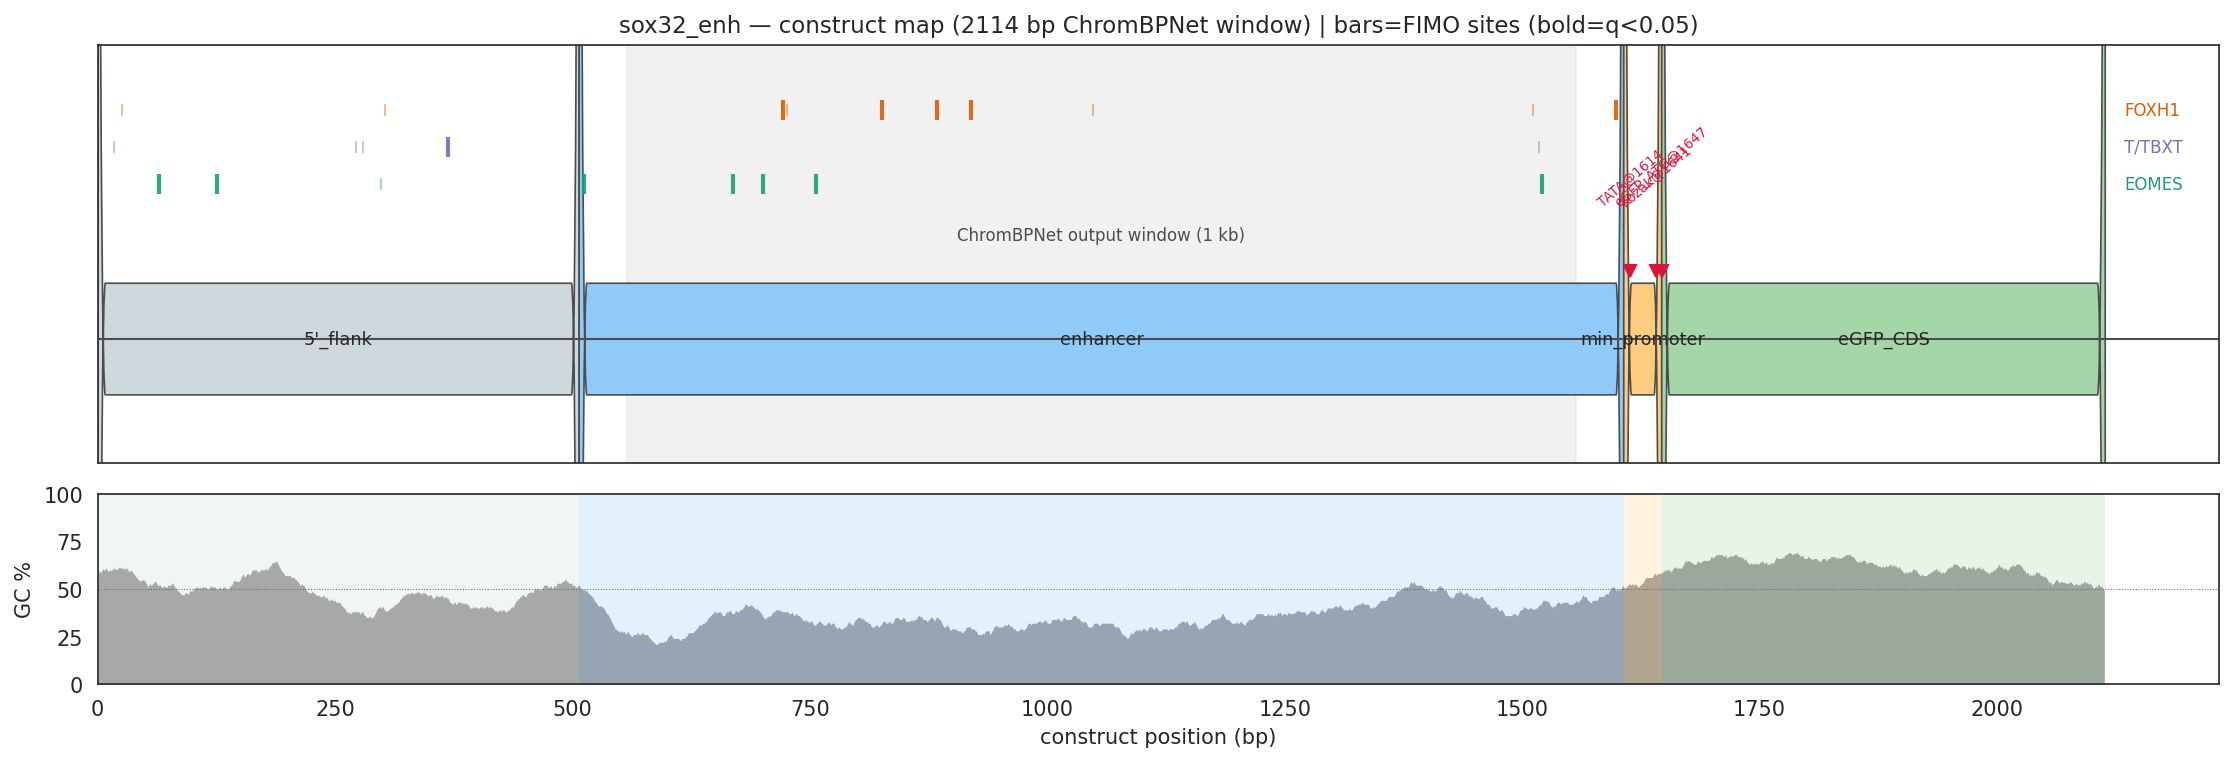

In [2]:
name, seq = cl.read_fasta(config.FASTA)
print(name, len(seq), 'bp')
for lab, a, b in config.FEATURES:
    print(f'  {lab:14s} {a:5d}-{b:<5d} {b-a:5d} bp')
print('  eGFP ATG at', seq.find('ATGGTGAGCAAGGGC'), '| TATA@1614:', seq[1611:1624], '| Kozak:', seq[1641:1647])
display(Image(f'{FIG}/sox32_construct_map.png'))

## 2. Model & prediction method

- **Models:** per-cell-type **ChromBPNet `chrombpnet_nobias.h5`** (Tn5-bias-removed accessibility) for 22 cell types (`config.MODELS_ROOT`). So predictions/contributions reflect *sequence-driven* accessibility.
- **Prediction** (`chrombpnet_locus.predict`): forward + reverse-complement, average; `counts = exp(count-head)` (total predicted reads over the 1 kb window), `profile = softmax(profile-head)`; the displayed track is `counts × profile`.
- **Two sequence variants** (both keep the enhancer at native 507–1607 coords):
  - `construct` — the 2114 bp window as-is.
  - `enh_dinuc` — keep the enhancer, **dinucleotide-shuffle** the flanking vector/promoter/reporter (native-like read; GC reporter context removed; via `tangermeme.ersatz.dinucleotide_shuffle`).
- **Contributions** (`count_contributions`): DeepLIFT/SHAP on the count head, dinuc-shuffle references, `n_shuffles=20`, **seeded** (`random_state=0`) for reproducibility.

⚠️ **Cross-cell-type counts are each on that model's own scale** (not normalized) — magnitude comparisons across cell types are approximate; within-lineage trends (e.g. PGT1→PGT3) are the robust signal.

## 3. Predicted accessibility across the trajectory (the reporter readout)

Does the model show DE-on / PGT-off? Counts in developmental order; `enh_dinuc` = enhancer with shuffled flanks.

,DE,PGT1,PGT2,PGT3,PFG1,PFG2,PP1,PP2,ENP_phase1,early_ENP,late_ENP,early_SC_beta,late_SC_beta,early_SC_alpha,late_SC_alpha,early_SC_EC,late_SC_EC,SC_delta_GHRL,proliferating_endocrine,exocrine,liver,FB_FLT1
construct,107.0,150.0,51.0,31.0,76.0,124.0,168.0,190.0,35.0,119.0,20.0,176.0,104.0,68.0,77.0,111.0,99.0,17.0,19.0,84.0,41.0,14.0
enh_dinuc,122.0,225.0,63.0,40.0,129.0,205.0,227.0,304.0,45.0,137.0,23.0,236.0,123.0,85.0,95.0,168.0,104.0,20.0,24.0,93.0,47.0,16.0


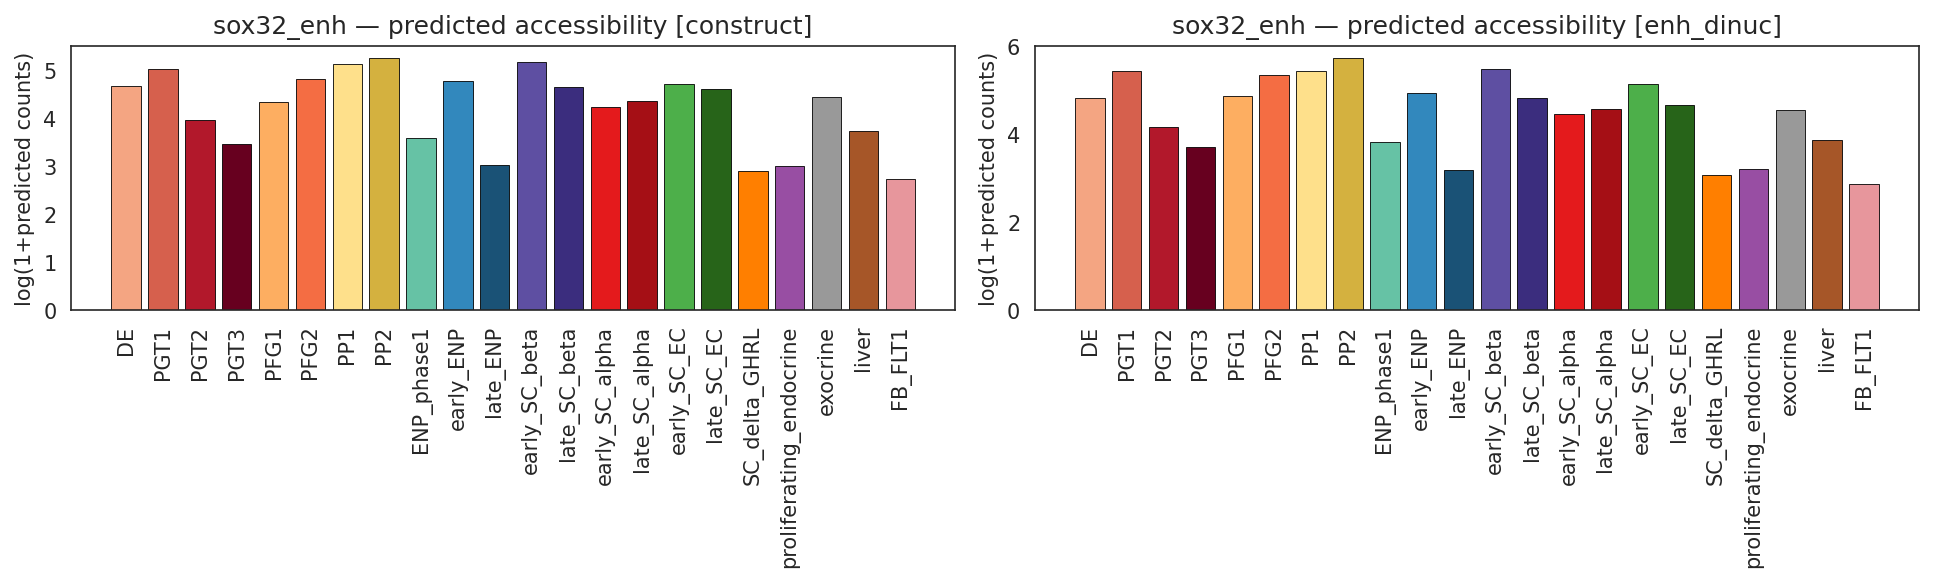

In [3]:
traj = res.ordered_celltypes()
acc = pd.DataFrame({'construct': [res.counts('construct', c) for c in traj],
                    'enh_dinuc': [res.counts('enh_dinuc', c) for c in traj]}, index=traj).round(0)
display(acc.T)
display(Image(f'{FIG}/sox32_all_accessibility_bar.png'))

**Read:** clear **PGT shut-down** (PGT1 → PGT2 → PGT3) and lowest in non-endoderm (FB_FLT1). **But PGT1 ≥ DE** — the model does not make DE the peak; shutdown is delayed to PGT2/3. Removing the flanks (`enh_dinuc`) boosts everything ~1.2–1.4× but preserves the ordering.

❓ **Judgment call:** is 'high through PGT1, off by PGT2/3' consistent with the reporter's 'on in DE, off in PGT', or a real discrepancy (DE-vs-early-PGT timing)?

## 4. Where are the EOMES / T / FOXH1 motifs? (FIMO — sequence, model-independent)

MEME-suite **FIMO v5.5.0** scan of the construct with HOCOMOCO H12 PWMs for the 3 TFs (p<1e-3), each hit tagged with the construct feature it falls in (`config.feature_of`). This asks *are the motifs present?* — independent of what the model attributes.

q<0.05 hits by feature x TF:
feature   motif_id
5'_flank  EOMES       2
          T_TBXT      1
enhancer  EOMES       5
          FOXH1       5
dtype: int64


,motif_id,start,stop,strand,p-value,q-value,feature,matched_sequence
0,FOXH1,718,726,+,0.000008,0.00804,enhancer,tgtggattc
1,EOMES,1516,1526,+,0.000021,0.01650,enhancer,aaggtgtcaaa
2,T_TBXT,359,378,-,0.000022,0.02380,5'_flank,TGAGCACGAGGGGGTGACAT
3,EOMES,121,131,+,0.000096,0.02830,5'_flank,taggtgtcatt
4,FOXH1,880,888,+,0.000102,0.03320,enhancer,agtgtattc
5,FOXH1,822,830,+,0.000113,0.03320,enhancer,tgtttattg
6,EOMES,751,761,+,0.000129,0.02830,enhancer,aaagtgtgacc
7,FOXH1,916,924,+,0.000133,0.03320,enhancer,tgttgattt
8,EOMES,696,706,-,0.000145,0.02830,enhancer,AACGTGTGACT
9,FOXH1,1595,1603,-,0.000234,0.04670,enhancer,TGTGTAGTG


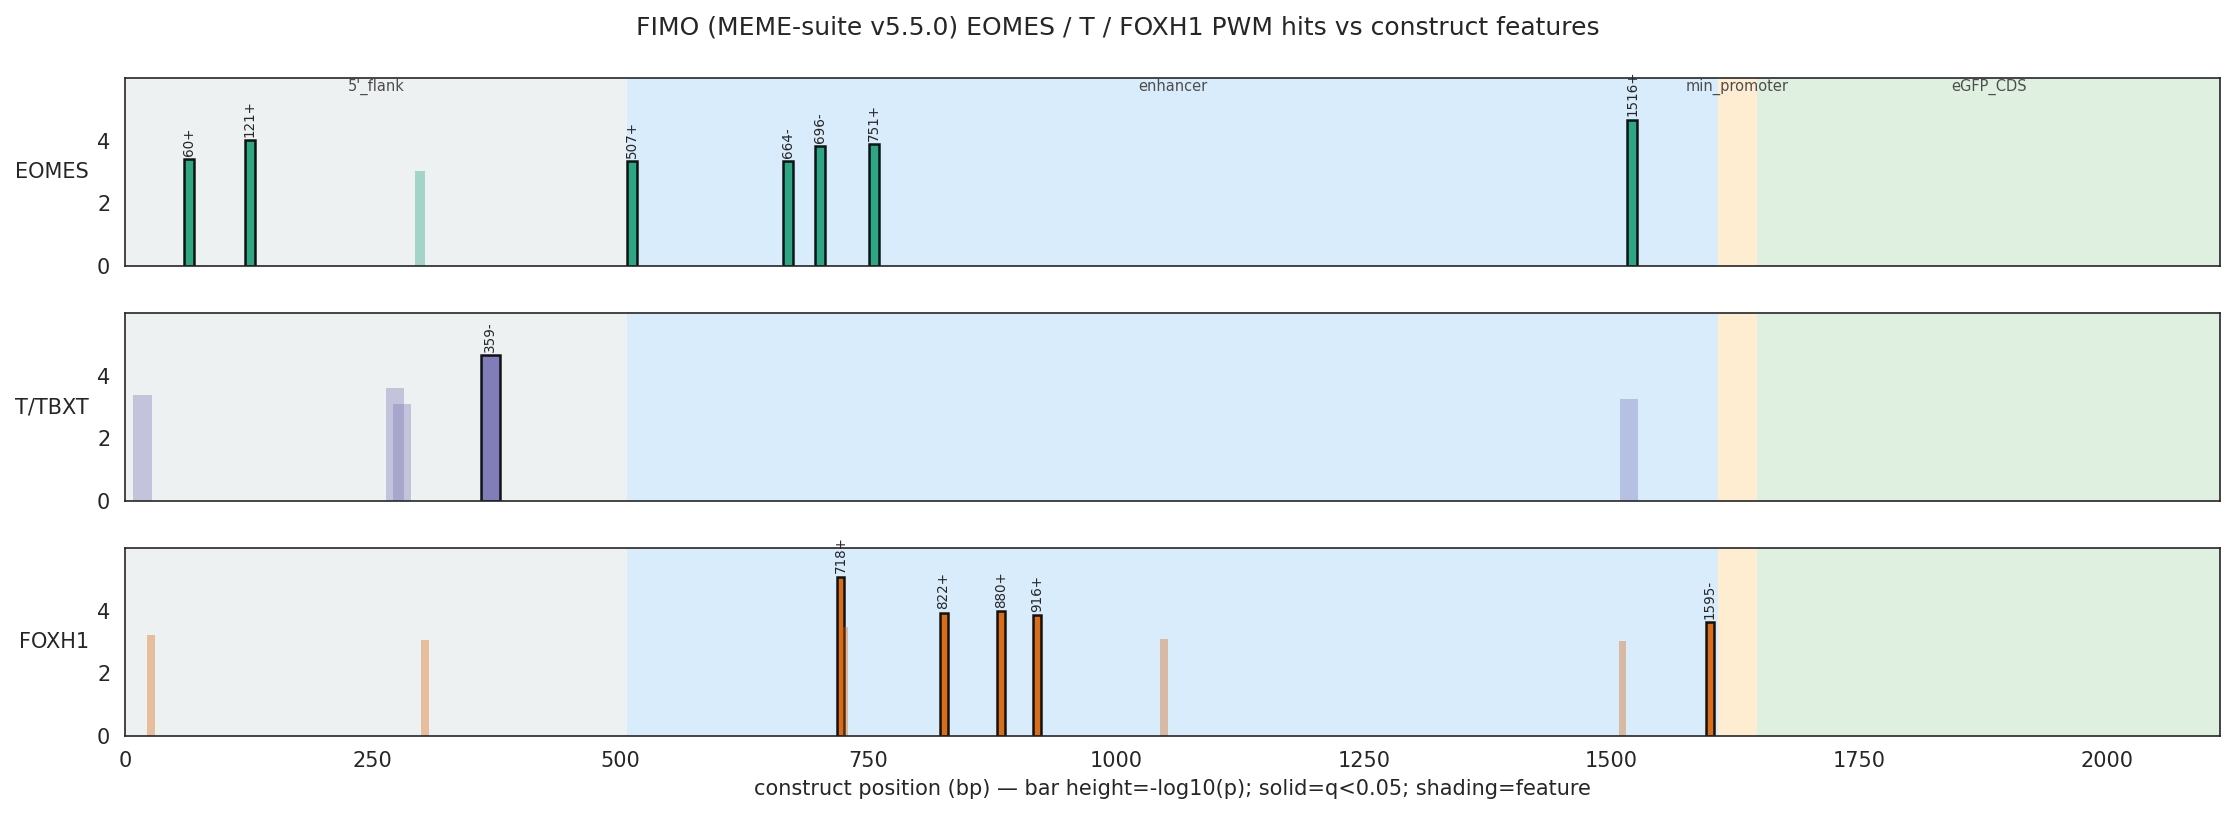

In [4]:
f = pd.read_csv(f'{OUT}/fimo/sox32_fimo_hits.csv')
print('q<0.05 hits by feature x TF:')
print(f[f['q-value'] < 0.05].groupby(['feature', 'motif_id']).size())
display(f[f['q-value'] < 0.05][['motif_id','start','stop','strand','p-value','q-value','feature','matched_sequence']].reset_index(drop=True))
display(Image(f'{FIG}/sox32_fimo_hitmap.png'))

**Read:** EOMES and FOXH1 sites are real and concentrated in the **enhancer** (incl. a FOXH1 site at ~718 abutting the EOMES cluster ~660–760 — the classic Nodal EOMES+FoxH1 composite); a few in the 5′ flank; **none in the promoter/eGFP**. So the *sequence* supports the collaborator's claim.

## 5. Contribution scores & seqlets (what the model *weights*) — with caveats

Per cell type we compute count-head DeepLIFT/SHAP contributions, call seqlets (pooled across cells; `recursive_seqlets`), and TOMTOM-annotate them against **3 DBs**: the project ChromBPNet catalog, the 3 named TFs, and full Vierstra. The per-cell-type panels (left: accessibility track; right: contribution logo with native Vierstra seqlet labels) are the saved figures below.

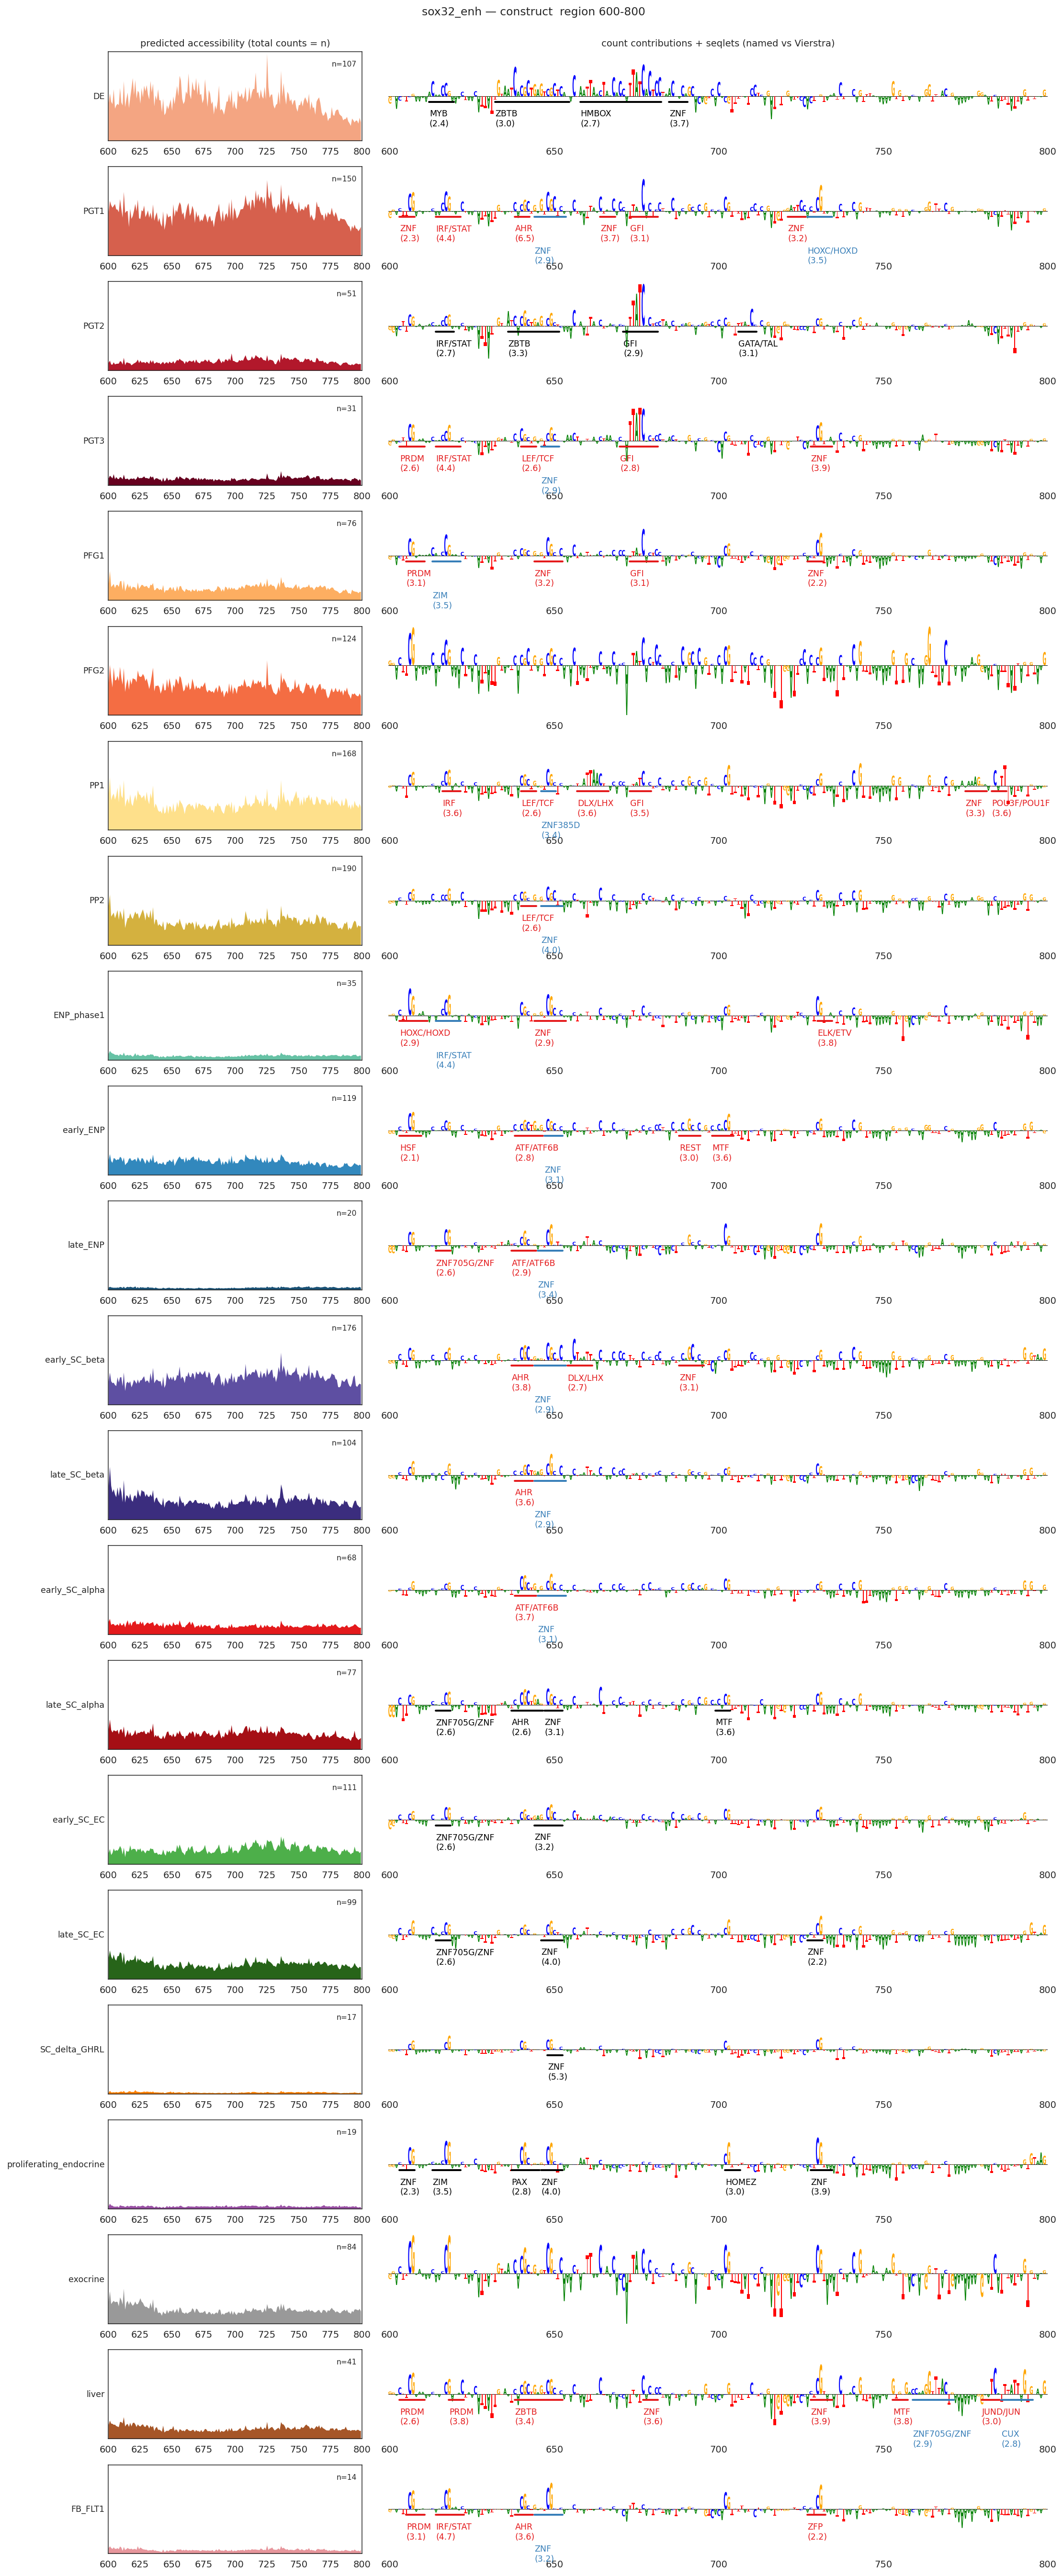

DE seqlets (top 10 by seqlet p-value) — note named3 vs vierstra disagreement:


,start,end,feature,named3_label,named3_pvalue,vierstra_label,vierstra_pvalue
0,658,683,enhancer,EOMES,0.015646,AC0472:HMBOX:Homeodomain AC0472:HMBOX:Homeodomain,0.001917
1,1379,1386,enhancer,EOMES,0.073473,AC0386:ZNF:C2H2_ZF AC0386:ZNF:C2H2_ZF,0.001122
2,1359,1365,enhancer,EOMES,0.226096,AC0282:MYBL:Myb/SANT AC0282:MYBL:Myb/SANT,0.000084
3,612,620,enhancer,FOXH1,0.124621,AC0276:MYB:Myb/SANT AC0276:MYB:Myb/SANT,0.003703
4,632,655,enhancer,T/TBXT,0.173418,AC0355:ZBTB:C2H2_ZF AC0355:ZBTB:C2H2_ZF,0.000973
5,1555,1560,enhancer,EOMES,0.022448,AC0442:TOPORS:Unknown AC0442:TOPORS:Unknown,0.000022
6,685,691,enhancer,FOXH1,0.039616,AC0393:ZNF:C2H2_ZF AC0393:ZNF:C2H2_ZF,0.000223
7,1365,1379,enhancer,EOMES,0.272999,AC0421:ZNF:C2H2_ZF AC0421:ZNF:C2H2_ZF,0.000129
8,1389,1399,enhancer,FOXH1,0.098556,AC0375:ZBTB:C2H2_ZF AC0375:ZBTB:C2H2_ZF,0.000032
9,989,998,enhancer,FOXH1,0.061180,AC0416:ZNF:C2H2_ZF AC0416:ZNF:C2H2_ZF,0.000607


In [5]:
display(Image(f'{FIG}/sox32_all_construct_zoom_EOMES_Tbox_600_800.png'))
t = pd.read_csv(f'{OUT}/sox32_all_construct_seqlets.csv')
print('DE seqlets (top 10 by seqlet p-value) — note named3 vs vierstra disagreement:')
display(t[t.celltype == 'DE'].nsmallest(10, 'seqlet_pvalue')[
    ['start','end','feature','named3_label','named3_pvalue','vierstra_label','vierstra_pvalue']].reset_index(drop=True))

⚠️ **Critical caveats — read before trusting the motif attribution:**
1. **Seqlet calling is fragile** on a single locus; we pool tracks across cell types to stabilize the null, but boundaries still move.
2. **DeepLIFT/SHAP is stochastic** (shuffle references). We now seed it (`random_state=0`), but the *current* npz was generated before the seed — its exact seqlet labels are one draw. A reseeded rerun will lock them.
3. **Forcing nearest-of-3** (named3) over-calls EOMES/FOXH1; the unbiased Vierstra often calls the same DE seqlets **HMBOX / ZNF / MYB**, not T-box/forkhead, at low p. So **the model does not reproducibly attribute accessibility specifically to EOMES/T/FOXH1** even though the motifs are present (§4).

➡️ **Implication:** seqlet-boundary annotation is the wrong tool for 'does the model care about motif X'. The rigorous test is **marginalization** (insert/ablate the motif, measure Δaccessibility) — not yet done (see §9).

## 6. Motif identities — Vierstra archetype relationships

Each TF's HOCOMOCO logo next to its nearest Vierstra consensus archetype, and a browsable HTML of the full cluster + DBD family memberships.

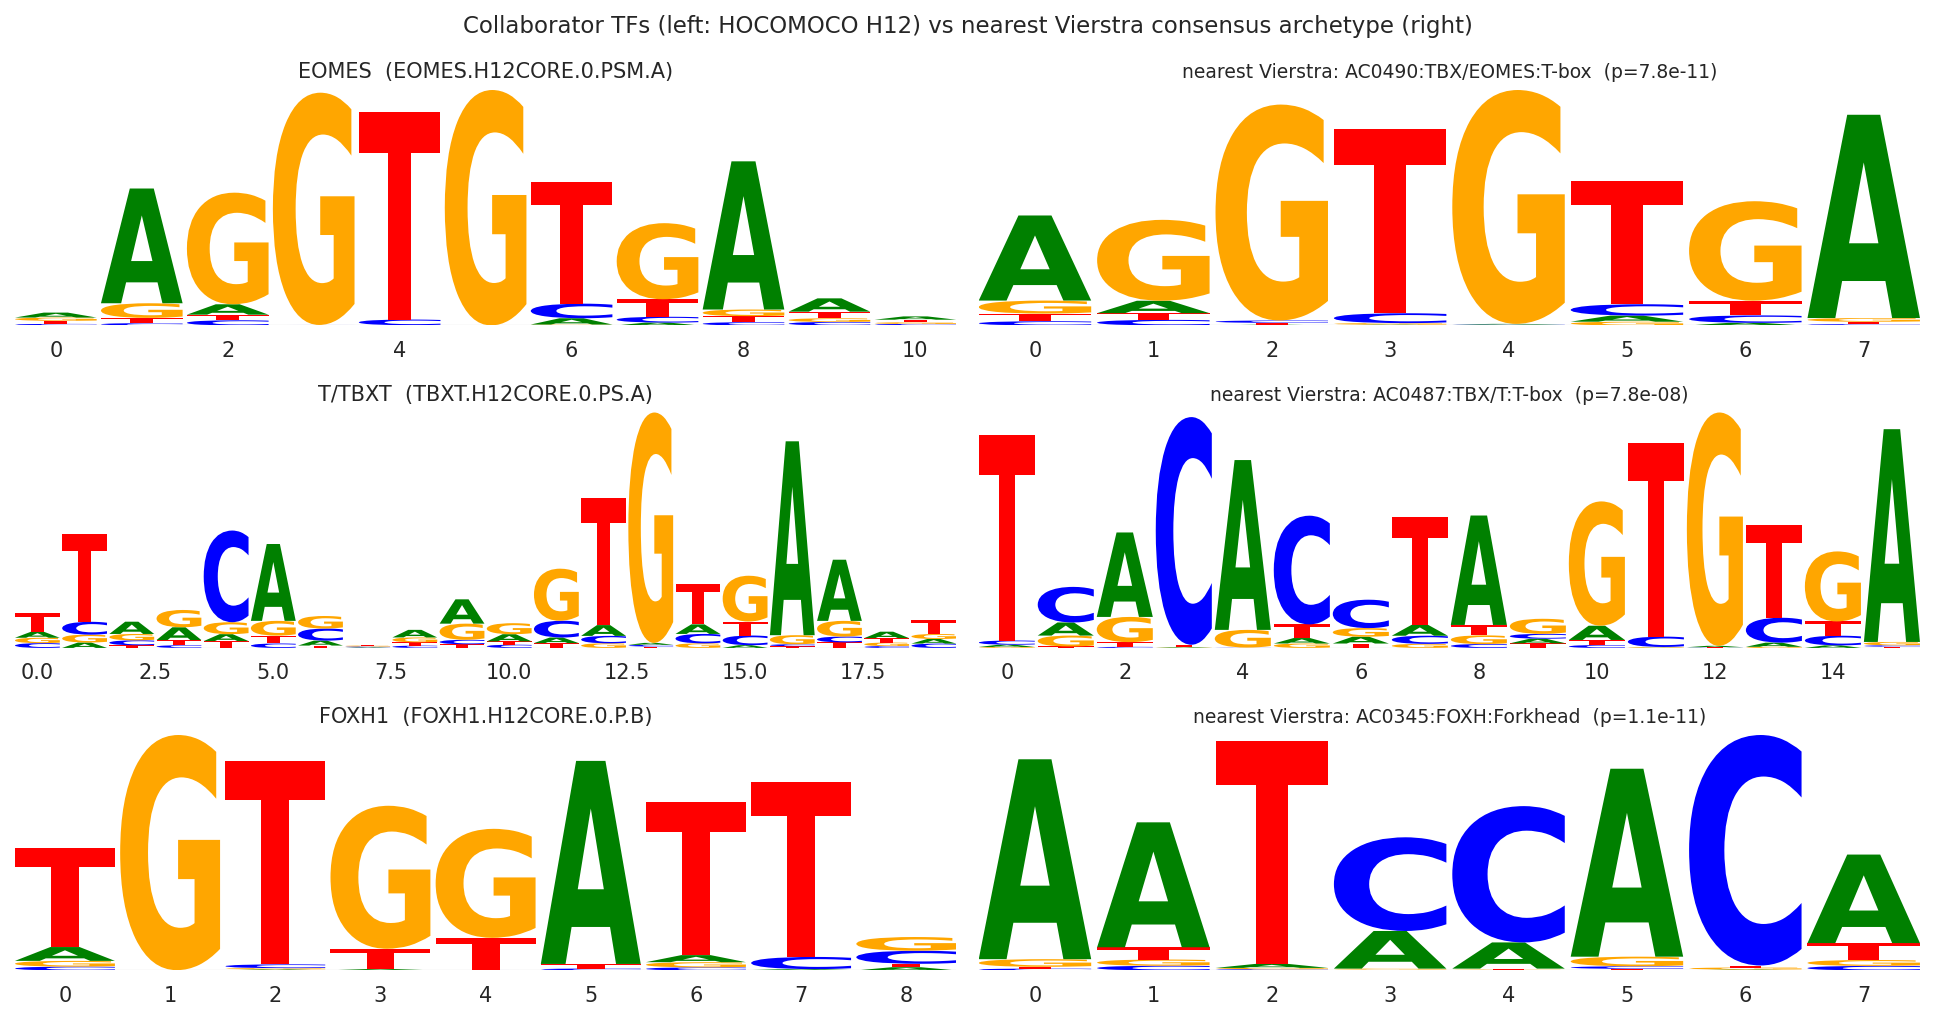

# EOMES / T / FOXH1 — Vierstra archetype relationships


## EOMES (EOMES.H12CORE.0.PSM.A)
- Nearest Vierstra consensus: **AC0490:TBX/EOMES:T-box** (p=7.8e-11)
- xlsx archetype **TBX/3** (cluster 72, DBD=TBX, 5 members): TBX21_HUMAN.H11MO.0.A, TBX3_MOUSE.H11MO.0.B, TBX21_MOUSE.H11MO.0.A, TBX3_HUMAN.H11MO.0.C, EOMES_TBX_2
- xlsx archetype **TBX/4** (cluster 73, DBD=TBX, 34 members): ZNF18_HUMAN.H11MO.0.C, EOMES_MA0800.1, TBR1_MA0802.1, TBX21_MA0690.1, TBX2_MA0688.1, MGA_MA0801.1, TBX1_MA0805.1, TBX20_MA0689.1...

## T/TBXT (TBXT.H12CORE.0.PS.A)
- Nearest Vierstra consensus: **AC0487:TBX/T:T-box** (p=7.8e-08)
- xlsx archetype **TBX/1** (cluster 70, DBD=TBX, 6 members): BRAC_HUMAN.H11MO.0.A, BRAC_MOUSE.H11MO.0.B, TBX19_MA0804.1, T_MA0009.2, TBX19_TBX_1, T_TBX_1

## FOXH1 (FOXH1.H12CORE.0.P.B)
- Nearest Vierstra consensus: **AC0345:FOXH:Forkhead** (p=1.1e-11)
- xlsx archetype **FOX/1** (cluster 76, DBD=forkhead, 2 members): FOXH1_HUMAN.H11MO.0.A, FOXH1_MA0479.1

## Summary
- EOMES and T (TBXT) are both **T-box (TBX)** DBD (shared AGGTGTGA core; Vierstra resolves them as separate consensus archetypes TBX/EOMES vs TBX/T).
- FOXH1 is **forkhead (FOX)** (TGTGGATT core), a distinct archetype.
- So T-box contribution footprints can be EOMES or T; FOXH1 is separable.


In [6]:
display(Image(f'{FIG}/sox32_TF_vierstra_relationships.png'))
display(Markdown(open(f'{OUT}/sox32_TF_vierstra_relationships.md').read()))
display(HTML('<a href="figures/sox32_vierstra_cluster_browser.html" target="_blank">→ open the Vierstra cluster/family browser (member logos)</a>'))

**Read:** EOMES & T are both **T-box** (resolvable archetypes TBX/EOMES vs TBX/T); FOXH1 is **forkhead**. So a T-box footprint can be EOMES *or* T; FOXH1 is separable. This is why named-3 labels conflate EOMES/T.

## 7. Context dependence — sequence sweeps (dinucleotide-shuffled non-kept bits)

- **keepcenter:** keep a central window of width W, dinuc-shuffle the flanks; sweep W from full construct (2114) down to a core. Isolates the enhancer as the flanking promoter/vector is removed.
- **slide:** keep the whole enhancer and slide it across the receptive field; flanks dinuc-shuffled. Positional sensitivity.

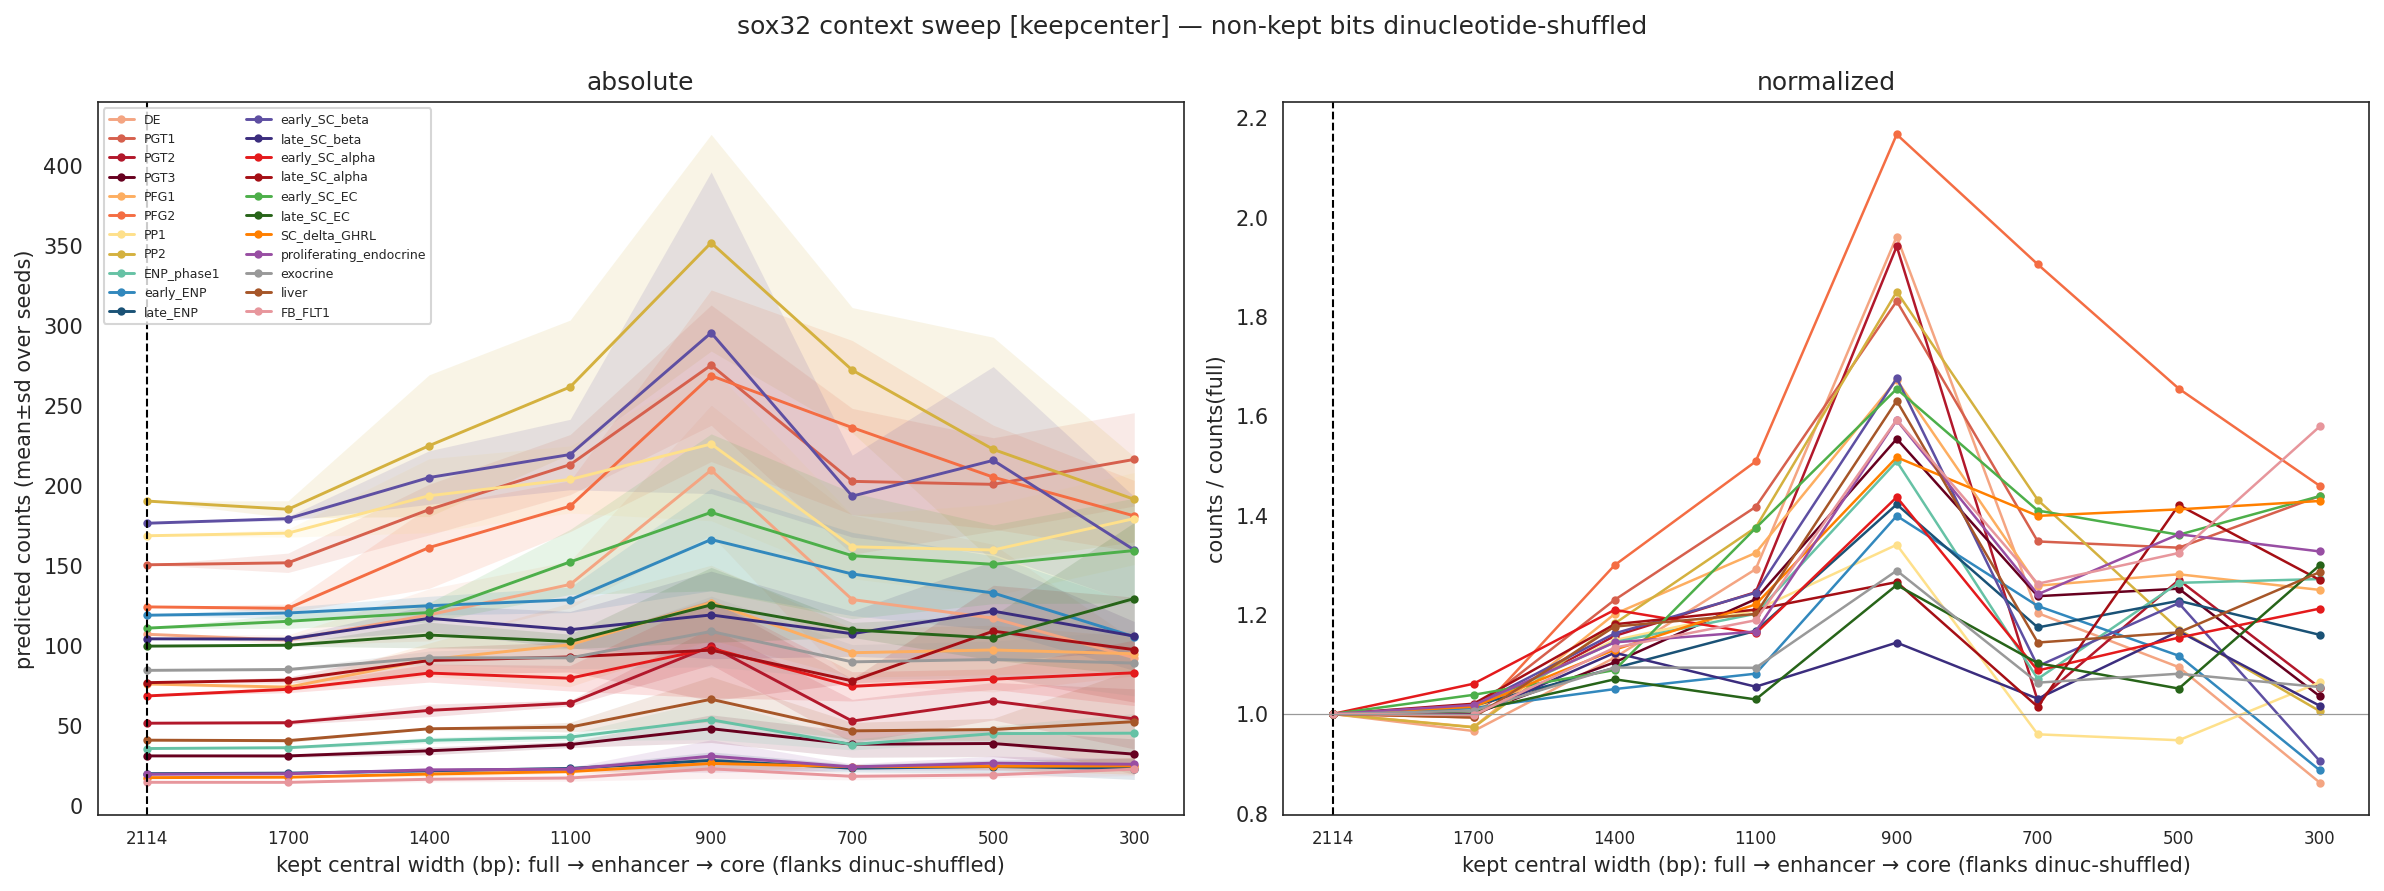

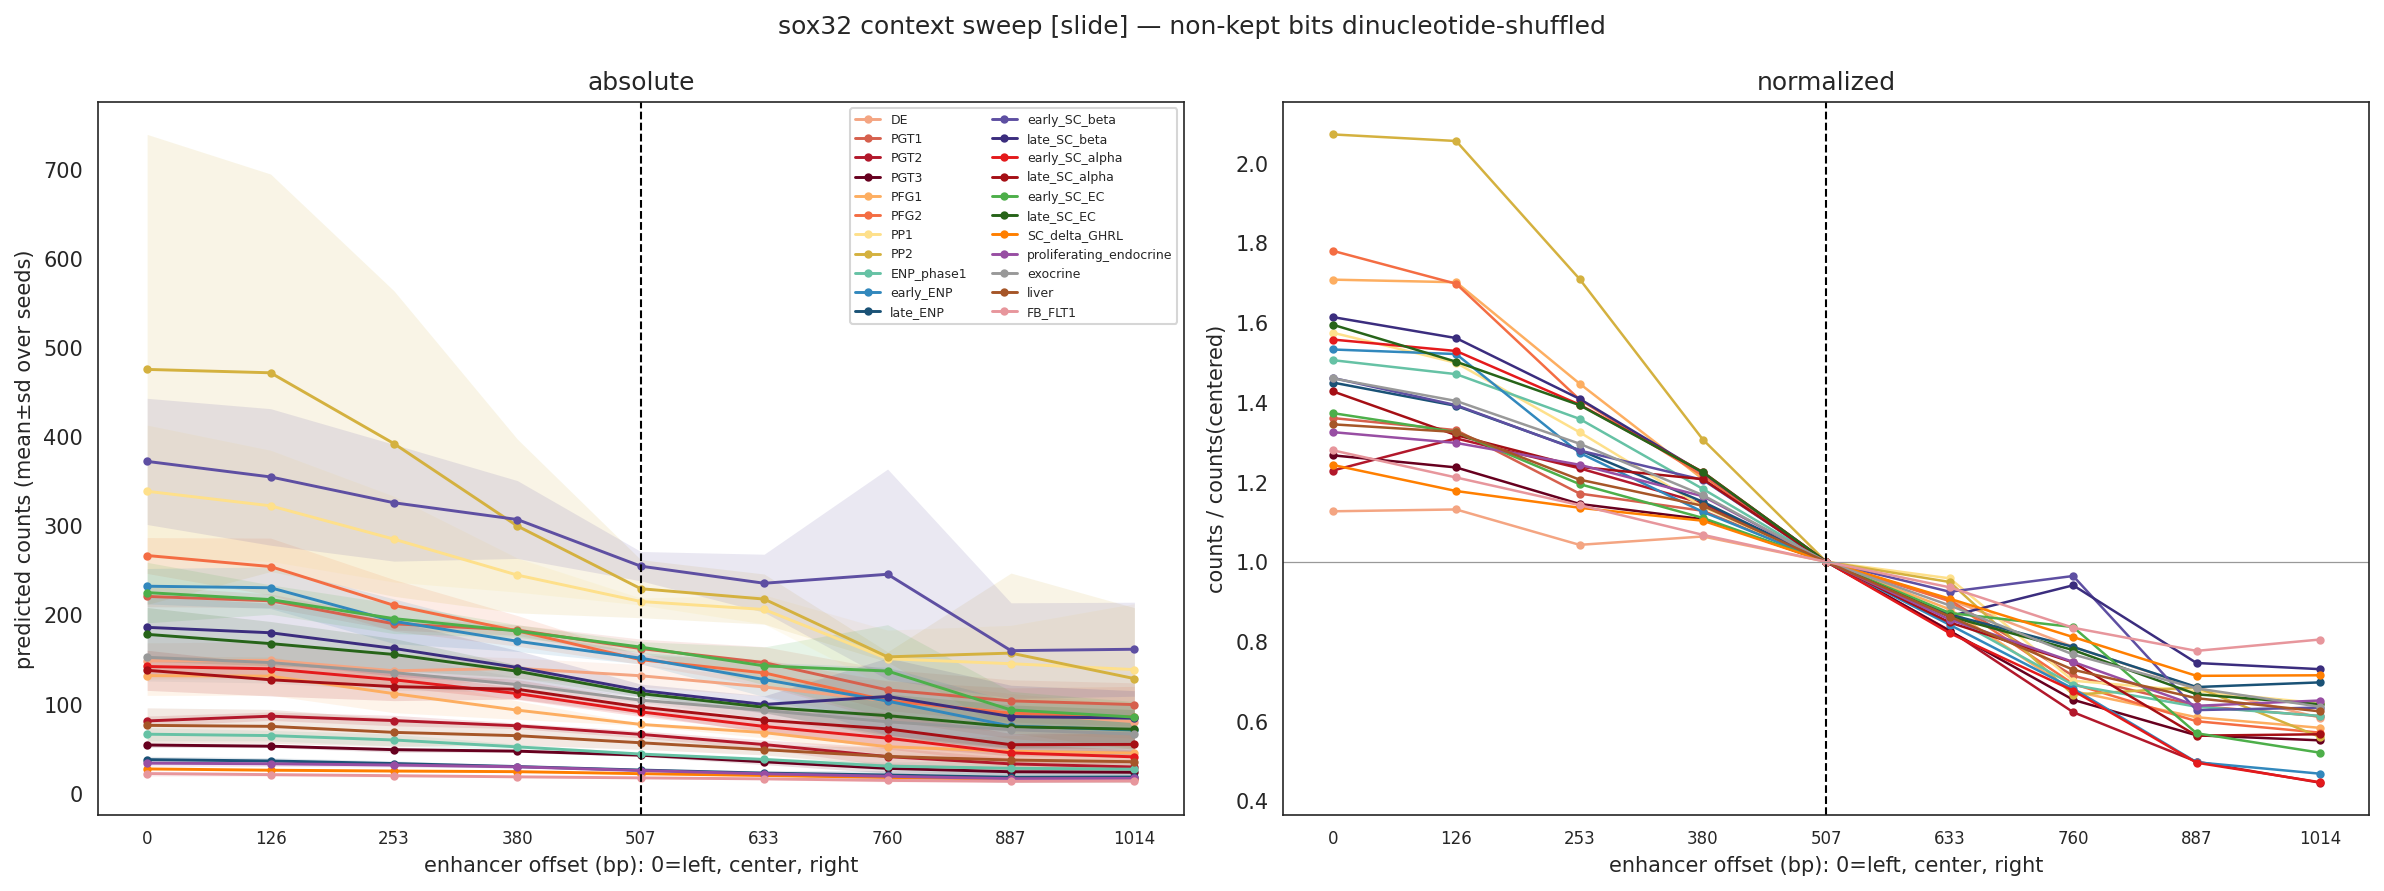

In [7]:
display(Image(f'{FIG}/sox32_context_sweep_keepcenter.png'))
display(Image(f'{FIG}/sox32_context_sweep_slide.png'))

**Read:** removing the GC-rich flanks (keepcenter → ~1100) **raises** predicted accessibility ~1.2–1.4× **uniformly** across cell types (not DE-specific), peaking near enhancer-only then dropping as we cut into the enhancer. So the reporter flank *dampens* the model's accessibility; the minimal promoter is **not** a strong accessibility driver in-model.

⚠️ **Modality gap:** the reporter measures **transcription** (a minimal promoter drives expression broadly); ChromBPNet predicts **accessibility**. A TATA promoter can be transcriptionally active but not broadly *accessible* — so model and reporter are not measuring the same thing in the flank.

## 8. Per-motif contribution across the trajectory

For each enhancer FIMO hit, the model's contribution summed over the hit window, per cell type. Absolute (robust scale) + row z-score (temporal pattern, magnitude removed).

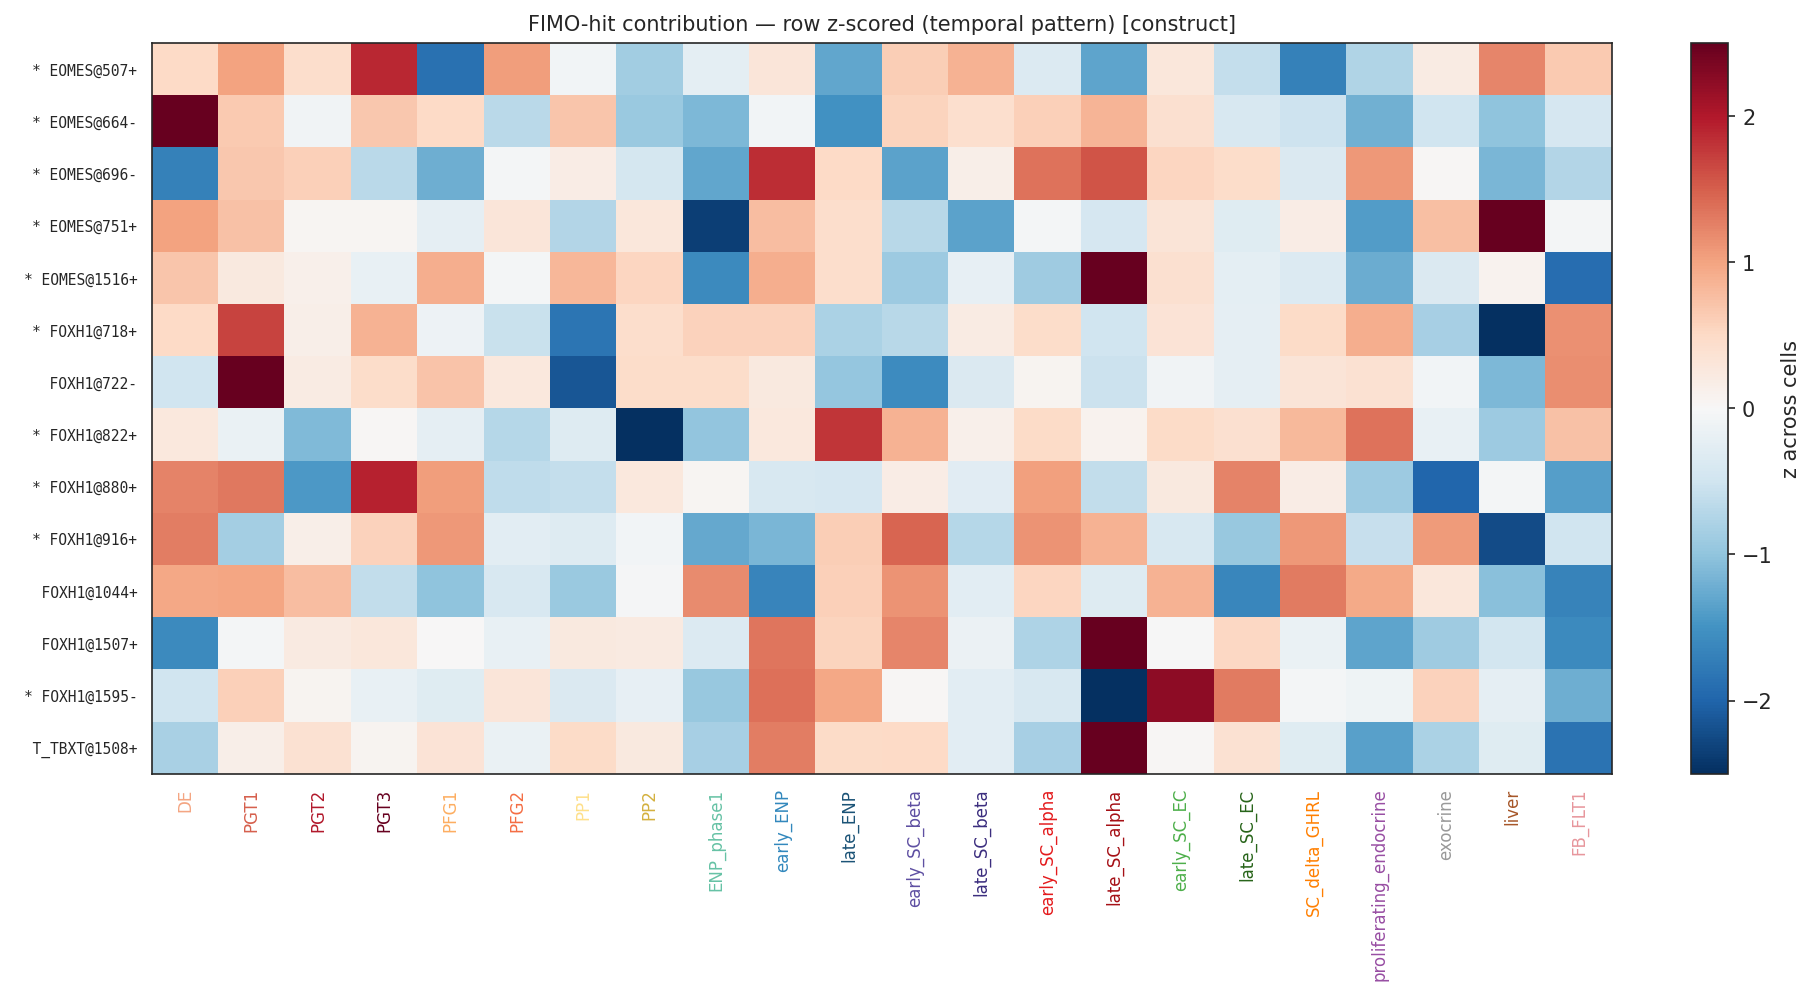

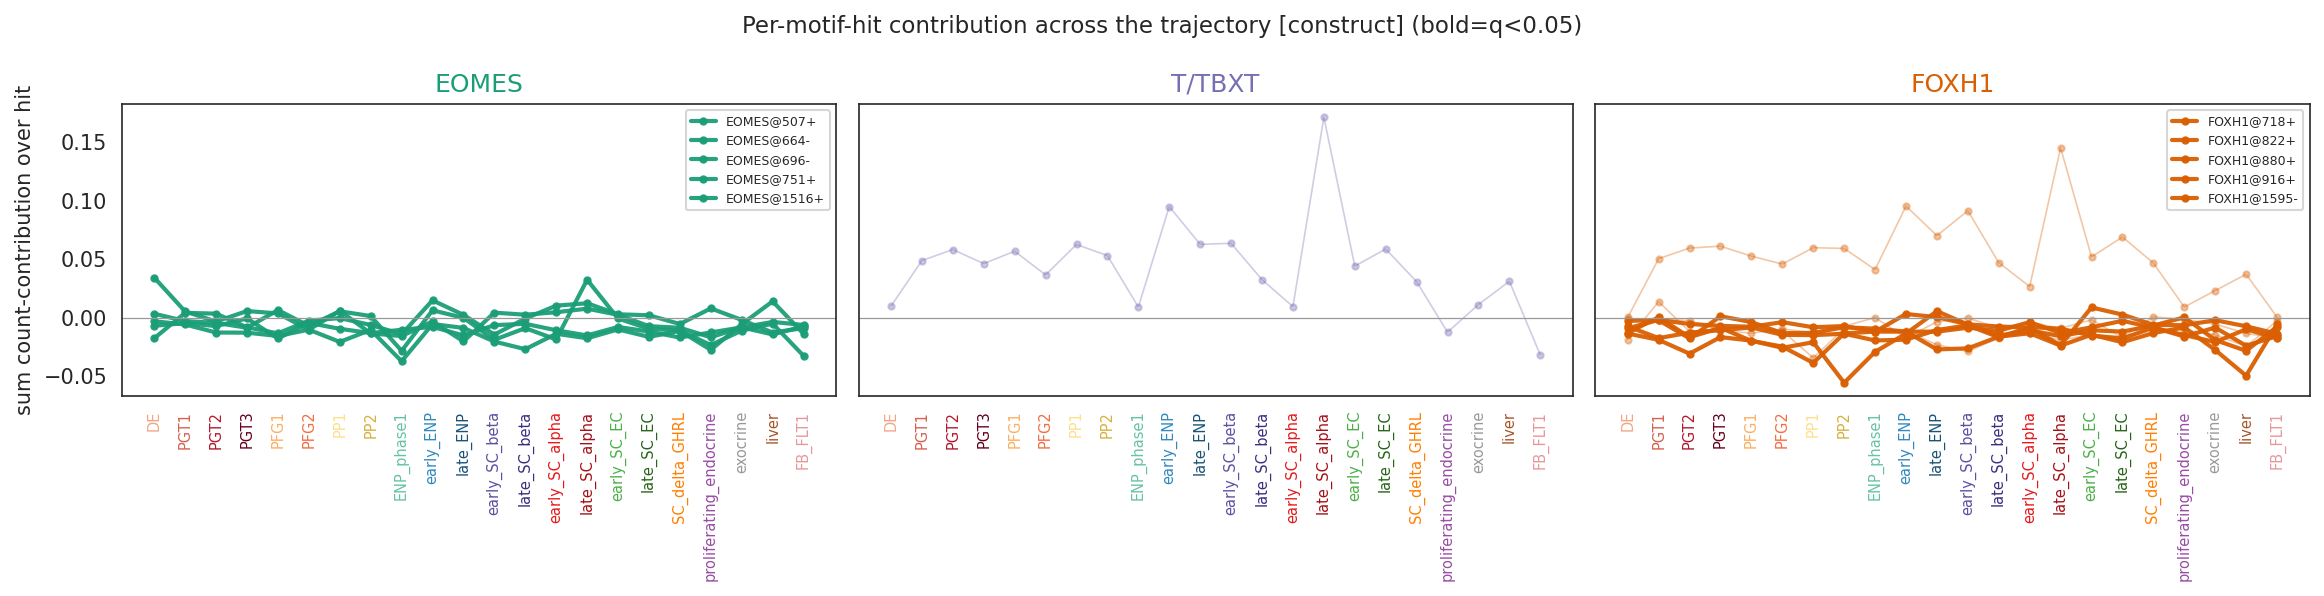

In [8]:
display(Image(f'{FIG}/sox32_fimo_contrib_heatmap_construct_zscore.png'))
display(Image(f'{FIG}/sox32_fimo_contrib_trajectory_construct.png'))

**Read (interpret cautiously — see §5 caveats):** in the z-scored view some T-box hits show their highest relative contribution in DE, but the pattern is noisy and run-sensitive. Treat as exploratory, confirm with marginalization.

## 9. Synthesis, assumptions, and **what we might be missing**

### Honest verdict
| question | answer |
|---|---|
| reproduce accessibility readout? | **partial** — PGT shut-down ✅; DE-as-peak ❌ (PGT1 ≥ DE) |
| are the TF motifs present? | **yes** (FIMO: EOMES×5, FOXH1×5 in enhancer) |
| does the model attribute accessibility to them? | **not reproducibly** — top seqlets map to homeodomain/ZNF; needs marginalization |

### Assumptions baked in (each is a place to double-check)
1. Enhancer = central 507–1607 (inferred from GC/TATA + collaborator) — exact ends approximate.
2. `chrombpnet_nobias` accessibility models; counts not normalized across models.
3. Contributions = count head only; `n_shuffles=20`; seeded now (npz predates seed).
4. FIMO p<1e-3, HOCOMOCO H12 PWMs; seqlet TOMTOM nearest-match.
5. `enh_dinuc` = dinuc-shuffled flanks (not the true zebrafish genomic flanks).

### What we might be missing (candidate gaps — please flag any that matter)
- [ ] **Marginalization** — insert/ablate each EOMES/T/FOXH1 site, measure Δaccessibility per cell type. The rigorous motif-effect test; not yet done.
- [ ] **Per-model count normalization** — to make cross-cell-type magnitudes comparable.
- [ ] **Profile-head contributions** — only count head done (footprint shape).
- [ ] **Reseeded rerun of `01_predict`** — lock contributions/seqlet labels (code seeded; outputs not yet).
- [ ] **Observed ATAC sanity** — do our cells actually show accessibility at the orthologous human SOX17 enhancer? (model-vs-data check)
- [ ] **Native genomic context** — predict the real danRer11 locus (needs coordinates) vs the construct.
- [ ] **Stage/identity match** — is dataset 'DE' the same stage as the reporter's DE? Is enhancer orientation in the construct = genome?
- [ ] **Variant/MPRA design** — if specific mutations are planned, score them (saturation mutagenesis).

### Proposed next step
Build **`08_marginalize.py`** (SLURM) for the motif-effect test, and reseed-rerun `01_predict`, before drawing firm conclusions about TF binding.